-------------**STRATEJİLER: Bollinger Bands**----------


 Bollinger Bands (Bollinger Bantları) stratejisini açıklayan ve aynı zamanda alım/satım sinyallerini fiyat grafiğiyle birlikte gösteren bir Python örneği vereceğim.

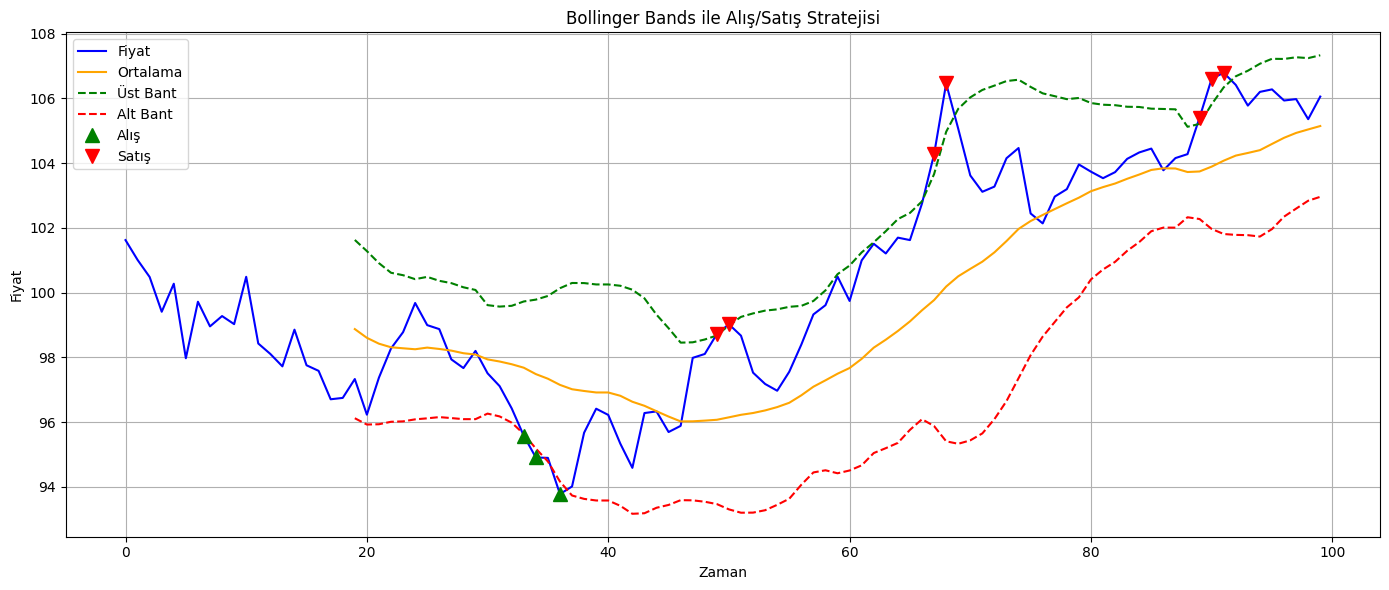

In [4]:
# Bollinger Bands Stratejisi ve Görselleştirme (Python)

import numpy as np
import matplotlib.pyplot as plt

def bollinger_bands(prices, window=20, num_std_dev=2):
    rolling_mean = np.convolve(prices, np.ones(window)/window, mode='valid')
    rolling_std = [np.std(prices[i-window:i]) for i in range(window, len(prices) + 1)]

    rolling_mean = np.array(rolling_mean)
    rolling_std = np.array(rolling_std)

    upper_band = rolling_mean + num_std_dev * rolling_std
    lower_band = rolling_mean - num_std_dev * rolling_std

    return rolling_mean, upper_band, lower_band

def bb_strategy(prices, upper_band, lower_band, offset):
    signals = []
    for i in range(len(prices)):
        if i < offset:
            signals.append(None)
        elif prices[i] < lower_band[i - offset]:
            signals.append('buy')
        elif prices[i] > upper_band[i - offset]:
            signals.append('sell')
        else:
            signals.append('hold')
    return signals

# Örnek veri
np.random.seed(1)
prices = np.cumsum(np.random.randn(100)) + 100

window = 20
mean, upper, lower = bollinger_bands(prices, window=window)
signals = bb_strategy(prices, upper, lower, offset=window - 1)

# Alış/Satış sinyalleri
buy_signals = [prices[i] if signals[i] == 'buy' else np.nan for i in range(len(signals))]
sell_signals = [prices[i] if signals[i] == 'sell' else np.nan for i in range(len(signals))]

# Grafik
plt.figure(figsize=(14, 6))
plt.plot(prices, label='Fiyat', color='blue')
plt.plot(range(window - 1, len(mean) + window - 1), mean, label='Ortalama', color='orange')
plt.plot(range(window - 1, len(upper) + window - 1), upper, label='Üst Bant', color='green', linestyle='--')
plt.plot(range(window - 1, len(lower) + window - 1), lower, label='Alt Bant', color='red', linestyle='--')
plt.plot(buy_signals, 'g^', label='Alış', markersize=10)
plt.plot(sell_signals, 'rv', label='Satış', markersize=10)
plt.title('Bollinger Bands ile Alış/Satış Stratejisi')
plt.xlabel('Zaman')
plt.ylabel('Fiyat')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

"""
Bu strateji, fiyat alt banda dokunduğunda “alış”, üst banda dokunduğunda “satış” sinyali üretir.
Bollinger bantları volatiliteye dayalı dinamik bir kanal sunar ve trend dönüşlerini yakalamada oldukça etkilidir.
"""